<a href="https://colab.research.google.com/github/Pedrogui29/TP547--Principios-de-Simulacao-de-Sistemas-de-Comunicacao/blob/main/simuladorfsk/fsk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simulador FSK**

*Alunos*: Henrique Corrêa e Pedro Guilherme

In [4]:
!pip install numpy
!pip install matplotlib
!pip install scipy

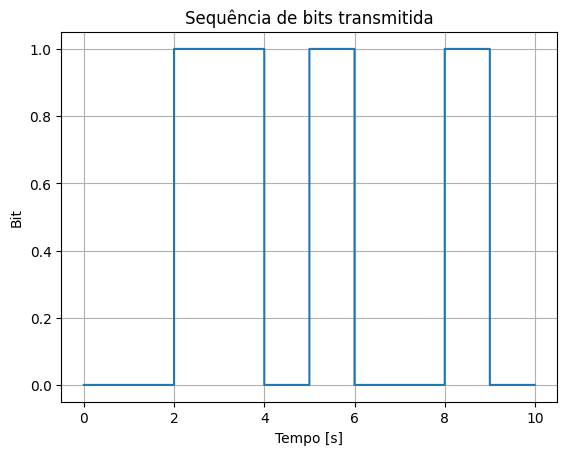

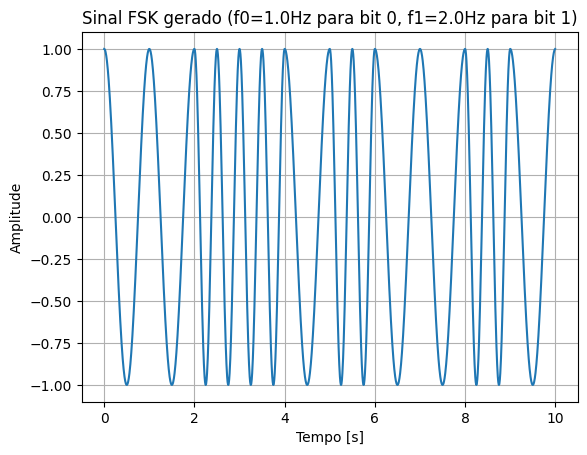

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal FSK
f0 = 1.0   # frequência portadora para bit 0 (Hz)
f1 = 2.0   # frequência portadora para bit 1 (Hz)
fs = 200   # frequência de amostragem (Hz)
Tb = 1.0   # duração de um bit (s)
n_bits = 10  # número de bits a transmitir

t_bit = np.linspace(0, Tb, int(fs * Tb), endpoint=False)
data = (np.random.rand(n_bits) > 0.5).astype(int)

# Geração do sinal FSK
fsk_signal = np.array([])
t_total = np.array([])
for i, bit in enumerate(data):
    freq = f1 if bit == 1 else f0
    segment = np.cos(2 * np.pi * freq * t_bit)
    fsk_signal = np.append(fsk_signal, segment)
    t_total = np.append(t_total, t_bit + i * Tb)

data_sequence = np.repeat(data, int(fs * Tb))

plt.figure(1)
plt.step(t_total, data_sequence, where='post')
plt.ylabel('Bit')
plt.xlabel('Tempo [s]')
plt.title('Sequência de bits transmitida')
plt.grid(True)

plt.figure(2)
plt.plot(t_total, fsk_signal)
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.title('Sinal FSK gerado (f0={}Hz para bit 0, f1={}Hz para bit 1)'.format(f0, f1))
plt.grid(True)

plt.show()

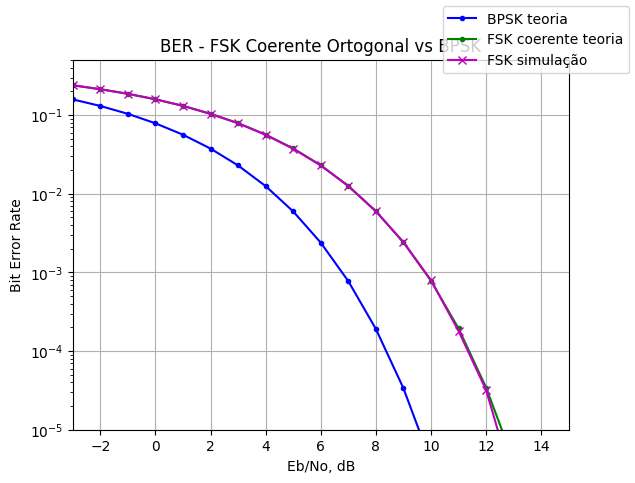

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

N = 10**6  # número de bits

simber = []

# Transmissor
ip = np.random.uniform(0, 1, N) > 0.5

s = 2 * ip - 1  # modulação FSK: bit 1 -> +1, bit 0 -> -1

Eb_N0_dB = np.arange(-3, 15, 1)

for ii in Eb_N0_dB:
    # Ruído gaussiano branco aditivo
    n = 1 / np.sqrt(2) * (np.random.normal(0, 1, N) + np.random.normal(0, 1, N) * 1j)

    y = s + np.sqrt(2) * 10 ** (-ii / 20) * n  # sinal recebido com AWGN

    ipHat = np.real(y) > 0

    ber = np.sum(ip != ipHat) / N  # BER simulada
    simber = np.append(simber, ber)

# Curvas teóricas
theoryBer_FSK  = 0.5 * special.erfc(np.sqrt(0.5 * 10 ** (Eb_N0_dB / 10)))  # FSK coerente
theoryBer_BPSK = 0.5 * special.erfc(np.sqrt(10 ** (Eb_N0_dB / 10)))         # BPSK

plt.semilogy(Eb_N0_dB, theoryBer_BPSK, 'b.-')
plt.semilogy(Eb_N0_dB, theoryBer_FSK, 'g.-')
plt.semilogy(Eb_N0_dB, simber, 'mx-')
plt.axis([-3, 15, 10 ** (-5), 0.5])
plt.grid()
plt.figlegend(['BPSK teoria', 'FSK coerente teoria', 'FSK simulação'])
plt.xlabel('Eb/No, dB')
plt.ylabel('Bit Error Rate')
plt.title('BER - FSK Coerente Ortogonal vs BPSK')
plt.show()